# Golden-scale self-similarity functional

This notebook evaluates the golden-scale self-similarity functional introduced in `pattern_search_in_mandelbrot.md`. The numerical core has been factored out into reusable helpers in `notebooks/pattern_search_common.py`, so the notebook now focuses on the experimental setup and the interpretation of the results.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from pattern_search_common import PHI, plot_patches, plot_search_result, run_single_ratio_search

plt.rcParams['figure.dpi'] = 120


This cell imports the shared helper module. The golden ratio `PHI` and the search/plotting routines are reused directly from `notebooks.pattern_search_common.py`, so the experimental code is no longer duplicated across notebooks.

In [2]:
BOUNDS = (-1.6, 0.4, -0.9, 0.9)
SEARCH_BOUNDS = (-1.05, -0.55, -0.35, 0.35)
N = 320
MAX_ITER = 200
R0 = 0.18
M = 3
PATCH_SIZE = 40
ANGLE_SAMPLES = 16
GRID_SHAPE = (17, 17)

experiment = run_single_ratio_search(
    BOUNDS,
    SEARCH_BOUNDS,
    N,
    MAX_ITER,
    R0,
    PHI,
    m=M,
    patch_size=PATCH_SIZE,
    angle_samples=ANGLE_SAMPLES,
    grid_shape=GRID_SHAPE,
)

best = experiment['best']
local_minima = experiment['local_minima']

print('Best center:', best['center'])
print('Best score:', round(best['score'], 6))
for item in best['errors']:
    print('n =', item['n'], 'radius =', round(item['radius'], 6), 'angle =', round(item['angle'], 6), 'error =', round(item['value'], 6))
print('Number of sampled local minima:', len(local_minima))
for item in local_minima:
    print('candidate center =', tuple(round(v, 6) for v in item['center']), 'score =', round(item['score'], 6))


Best center: (np.float64(-0.8), np.float64(0.0))
Best score: 0.037588
n = 1 radius = 0.068754 angle = 0.0 error = 0.039243
n = 2 radius = 0.026262 angle = 0.0 error = 0.046519
n = 3 radius = 0.010031 angle = 0.0 error = 0.050693
Number of sampled local minima: 11
candidate center = (np.float64(-0.8), np.float64(0.0)) score = 0.037588
candidate center = (np.float64(-0.83125), np.float64(-0.0875)) score = 0.040543
candidate center = (np.float64(-0.83125), np.float64(0.0875)) score = 0.040543
candidate center = (np.float64(-0.7375), np.float64(-0.30625)) score = 0.043004
candidate center = (np.float64(-0.7375), np.float64(0.30625)) score = 0.043004
candidate center = (np.float64(-1.05), np.float64(0.21875)) score = 0.043826
candidate center = (np.float64(-1.05), np.float64(-0.21875)) score = 0.043826
candidate center = (np.float64(-1.05), np.float64(-0.30625)) score = 0.044107
candidate center = (np.float64(-1.05), np.float64(0.30625)) score = 0.044107
candidate center = (np.float64(-0.61

This cell fixes the numerical parameters and evaluates the functional on the search grid. In the present run the best sampled point is
$$
x_{N,m} = (-0.8,0.0),
$$
with score approximately
$$
S_{N,m}(x_{N,m}) \approx 0.037588.
$$
The reported radii are exactly the scales
$$
r_n = r_0 \lambda^{-2n}, \qquad n=1,2,3.
$$
All sampled local minima of the score field on the finite grid are listed explicitly. This set is finite because the search grid is finite; over the countable family of finite sampling grids, the union of all such sampled candidate sets is at most countable.

In [3]:
print('All sampled candidate centers and scores:')
for item in local_minima:
    print(tuple(round(v, 6) for v in item['center']), round(item['score'], 6))


All sampled candidate centers and scores:
(np.float64(-0.8), np.float64(0.0)) 0.037588
(np.float64(-0.83125), np.float64(-0.0875)) 0.040543
(np.float64(-0.83125), np.float64(0.0875)) 0.040543
(np.float64(-0.7375), np.float64(-0.30625)) 0.043004
(np.float64(-0.7375), np.float64(0.30625)) 0.043004
(np.float64(-1.05), np.float64(0.21875)) 0.043826
(np.float64(-1.05), np.float64(-0.21875)) 0.043826
(np.float64(-1.05), np.float64(-0.30625)) 0.044107
(np.float64(-1.05), np.float64(0.30625)) 0.044107
(np.float64(-0.6125), np.float64(0.35)) 0.047231
(np.float64(-0.6125), np.float64(-0.35)) 0.047231


The candidate list is the discrete output of the search procedure for the present grid. These are the finite-grid Dudko-type candidates detected by the golden-scale functional.

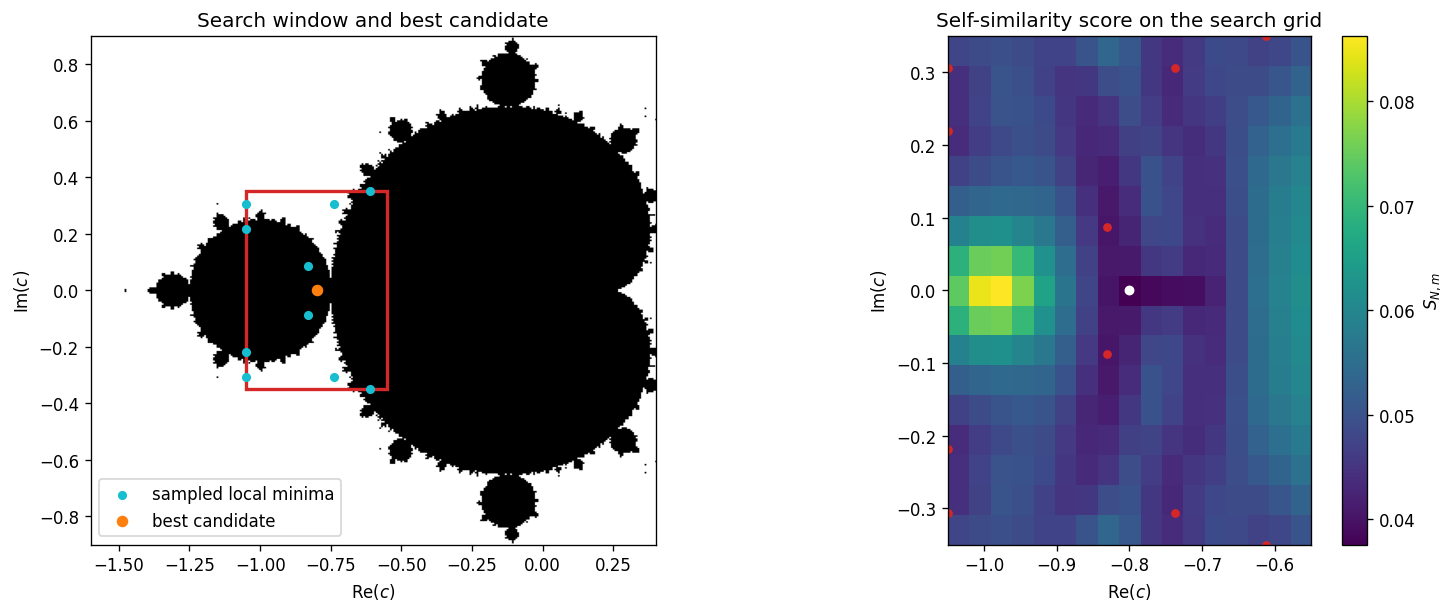

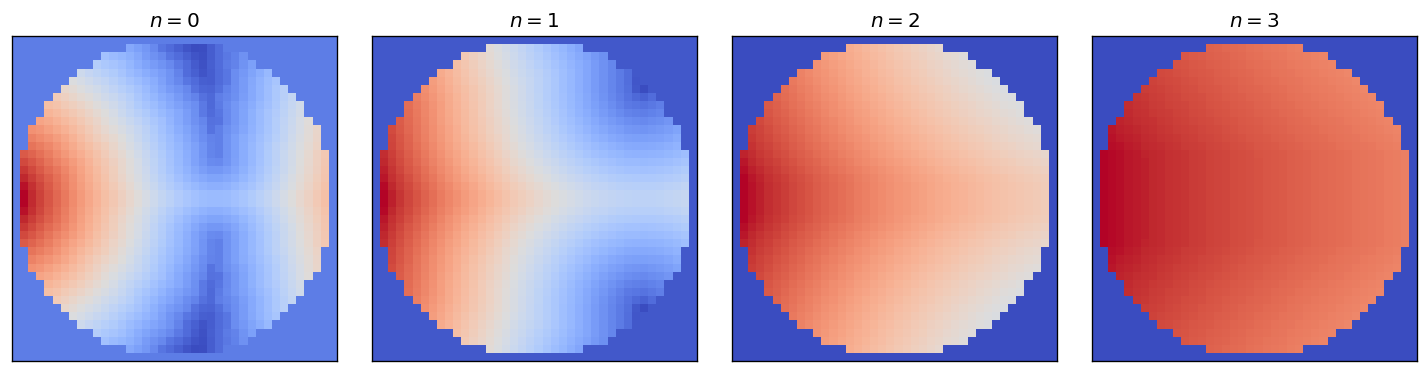

In [4]:
plot_search_result(
    experiment['indicator'],
    BOUNDS,
    SEARCH_BOUNDS,
    experiment['grid_xs'],
    experiment['grid_ys'],
    experiment['score_grid'],
    best,
    local_minima,
)
plt.show()

plot_patches(best, M)
plt.show()


The first figure shows the search window, the sampled local minima, and the score field. The second figure shows the normalized patches $f_{N,x,n}$ across the first few golden scales. Together they provide a proof-of-concept numerical signal for the self-similarity functional, but not a verification of the full Dudko prediction.